# Mushroom Classification
## Description:
Here, we will be training and examining different machine learning models on the task of identifying whether a mushroom is edible or not based on a set of physical and nonphysical features such as cap dimensions and odor.

### Part 1: Data Preprocessing

* #### Initial Exploration
1.  Load the dataset. Print the shape and the first 5 rows.

In [1]:
%matplotlib widget

import pandas as pandas
import seaborn as seaborn
import matplotlib.pyplot as pyplot
import numpy as numpy
from sklearn.model_selection import train_test_split

df = pandas.read_csv('expanded_csv.csv')
df = df.replace('?', numpy.nan)

pandas.set_option('display.max_colwidth', 20)
pandas.set_option('display.width', 1000)
pandas.set_option('display.max_columns', 10)
pandas.set_option('display.max_rows', None)

print("Dimensions:")
print(df.shape)
print("")

print("Info:")
print(df.info())
print("")

print("Head:")
print(df.head(5))
print("")

Dimensions:
(8416, 23)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8416 entries, 0 to 8415
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Edibility              8416 non-null   object
 1   CapShape               8416 non-null   object
 2   CapSurface             8416 non-null   object
 3   CapColor               8416 non-null   object
 4   Bruises                8416 non-null   object
 5   Odor                   8416 non-null   object
 6   GillAttachment         8416 non-null   object
 7   GillSpacing            8416 non-null   object
 8   GillSize               8416 non-null   object
 9   GillColor              8416 non-null   object
 10  StalkShape             8416 non-null   object
 11  StalkRoot              5936 non-null   object
 12  StalkSurfaceAboveRing  8416 non-null   object
 13  StalkSurfaceBelowRing  8416 non-null   object
 14  StalkColorAboveRing    8416 non-null   obj

2. Check for missing values in every column.

In [2]:
print("Null Value Counts:")
print(df.isnull().sum())
print("")

Null Value Counts:
Edibility                   0
CapShape                    0
CapSurface                  0
CapColor                    0
Bruises                     0
Odor                        0
GillAttachment              0
GillSpacing                 0
GillSize                    0
GillColor                   0
StalkShape                  0
StalkRoot                2480
StalkSurfaceAboveRing       0
StalkSurfaceBelowRing       0
StalkColorAboveRing         0
StalkColorBelowRing         0
VeilType                    0
VeilColor                   0
RingNumber                  0
RingType                    0
SporePrintColor             0
Population                  0
Habitat                     0
dtype: int64



3. For each column that has missing values, decide how to handle it.

In [3]:
dfnullsdropped = df.drop(["StalkRoot"], axis=1)
dfmodeimputed = df.copy()
dfmodeimputed.fillna(df.mode(dropna=True).iloc[0], inplace=True)

Due to my insufficient experience with mushrooms, for now I am making multiple versions of the dataset; dfrootsdropped for dropping the features with missing values wholesale, and dfmodeimputed for replacing the null values with the most common values of the features in question. In this case, the only feature which has missing values is StalkRoot. I also feel that removing the records with missing values isn't a viable option at all, because we'd be losing a quarter of the dataset despite only about 1% of the overall data missing.

4. Verify that no missing values remain.

In [4]:
print("Null Value Counts:")
print(dfnullsdropped.isnull().sum())
print("")
print(dfnullsdropped.shape)
print("")
print(dfmodeimputed.isnull().sum())
print("")
print(dfmodeimputed.shape)
print("")

Null Value Counts:
Edibility                0
CapShape                 0
CapSurface               0
CapColor                 0
Bruises                  0
Odor                     0
GillAttachment           0
GillSpacing              0
GillSize                 0
GillColor                0
StalkShape               0
StalkSurfaceAboveRing    0
StalkSurfaceBelowRing    0
StalkColorAboveRing      0
StalkColorBelowRing      0
VeilType                 0
VeilColor                0
RingNumber               0
RingType                 0
SporePrintColor          0
Population               0
Habitat                  0
dtype: int64

(8416, 22)

Edibility                0
CapShape                 0
CapSurface               0
CapColor                 0
Bruises                  0
Odor                     0
GillAttachment           0
GillSpacing              0
GillSize                 0
GillColor                0
StalkShape               0
StalkRoot                0
StalkSurfaceAboveRing    0
StalkSurfa

* #### Encode Categorical Features 
1.  Identify the string columns that can be meaningfully encoded. Apply the 
appropriate encoding method to each: 
    1) Binary columns with exactly two values to convert to 0/1.
    2) Columns with more than two categories to create one-hot encoded columns. 

In [5]:
#From Stack Overflow https://stackoverflow.com/questions/67221853/how-do-i-exclude-a-column-from-pandas-pd-get-dummies
columns_to_exclude = ['Bruises', 'GillSize', 'StalkShape', 'VeilType', 'RingNumber', 'Edibility']

dfnullsdropped = pandas.get_dummies(dfnullsdropped, columns=list(filter(
    lambda i: i not in columns_to_exclude,
    dfnullsdropped.columns)), dtype=int)
dfmodeimputed = pandas.get_dummies(dfmodeimputed, columns=list(filter(
    lambda i: i not in columns_to_exclude,
    dfmodeimputed.columns)), dtype=int)

dfnullsdropped["Bruises"] = dfnullsdropped["Bruises"].replace(["NO", "BRUISES"], ["0", "1"]).astype(int)
dfnullsdropped["GillSize"] = dfnullsdropped["GillSize"].replace(["NARROW", "BROAD"], ["0", "1"]).astype(int)
dfnullsdropped["StalkShape"] = dfnullsdropped["StalkShape"].replace(["TAPERING", "ENLARGING"], ["0", "1"]).astype(int)
dfnullsdropped["VeilType"] = dfnullsdropped["VeilType"].replace(["PARTIAL", "UNIVERSAL"], ["0", "1"]).astype(int)#No UNIVERSAL examples???
dfnullsdropped["RingNumber"] = dfnullsdropped["RingNumber"].replace(["NONE", "ONE", "TWO"], ["0", "1", "2"]).astype(int)
dfnullsdropped["Edibility"] = dfnullsdropped["Edibility"].replace(["POISONOUS", "EDIBLE"], ["0", "1"]).astype(int)

dfmodeimputed["Bruises"] = dfmodeimputed["Bruises"].replace(["NO", "BRUISES"], ["0", "1"]).astype(int)
dfmodeimputed["GillSize"] = dfmodeimputed["GillSize"].replace(["NARROW", "BROAD"], ["0", "1"]).astype(int)
dfmodeimputed["StalkShape"] = dfmodeimputed["StalkShape"].replace(["TAPERING", "ENLARGING"], ["0", "1"]).astype(int)
dfmodeimputed["VeilType"] = dfmodeimputed["VeilType"].replace(["PARTIAL", "UNIVERSAL"], ["0", "1"]).astype(int)#No UNIVERSAL examples???
dfmodeimputed["RingNumber"] = dfmodeimputed["RingNumber"].replace(["NONE", "ONE", "TWO"], ["0", "1", "2"]).astype(int)
dfmodeimputed["Edibility"] = dfmodeimputed["Edibility"].replace(["POISONOUS", "EDIBLE"], ["0", "1"]).astype(int)

print("Dropped")
print(dfnullsdropped.head())
print("")
print("Imputed")
print(dfmodeimputed.head())
print("")

Dropped
   Edibility  Bruises  GillSize  StalkShape  VeilType  ...  Habitat_MEADOWS  Habitat_PATHS  Habitat_URBAN  Habitat_WASTE  Habitat_WOODS
0          1        1         0           0         0  ...                0              0              0              0              1
1          1        1         0           0         0  ...                0              0              0              0              1
2          1        1         0           0         0  ...                0              0              0              0              1
3          1        1         0           0         0  ...                0              0              0              0              1
4          1        1         0           0         0  ...                0              0              0              0              1

[5 rows x 108 columns]

Imputed
   Edibility  Bruises  GillSize  StalkShape  VeilType  ...  Habitat_MEADOWS  Habitat_PATHS  Habitat_URBAN  Habitat_WASTE  Habitat_WOODS
0      

2. In a markdown cell, explain which method you used for each column and why 
one-hot encoding is preferred over label encoding for a nominal column like Embarked. 

GillAttachment and GillSpacing have been One-Hot-Encoded despite only having two values in the dataset because the UCI dataset description lists these features as having more options, so I'm choosing to respect that, in case additional data is found at some point in the future.

There are no records of any mushrooms with UNIVERSAL VeilType, nor any with NONE RingNumber. RingNumber will be treated as a continuous numerical value.

3. Drop the columns that cannot be meaningfully encoded. In a markdown cell, 
explain the reason for dropping each one. It might be different reasons even if the action 
is the same. 

In [6]:
#Nothing

All of the columns have been prepared, and none were deemed unmeaningful.

* #### Heatmap Visualization 
1.  Generate a correlation heatmap for all features in your DataFrame.

Heatmap Correlation
NullsDropped


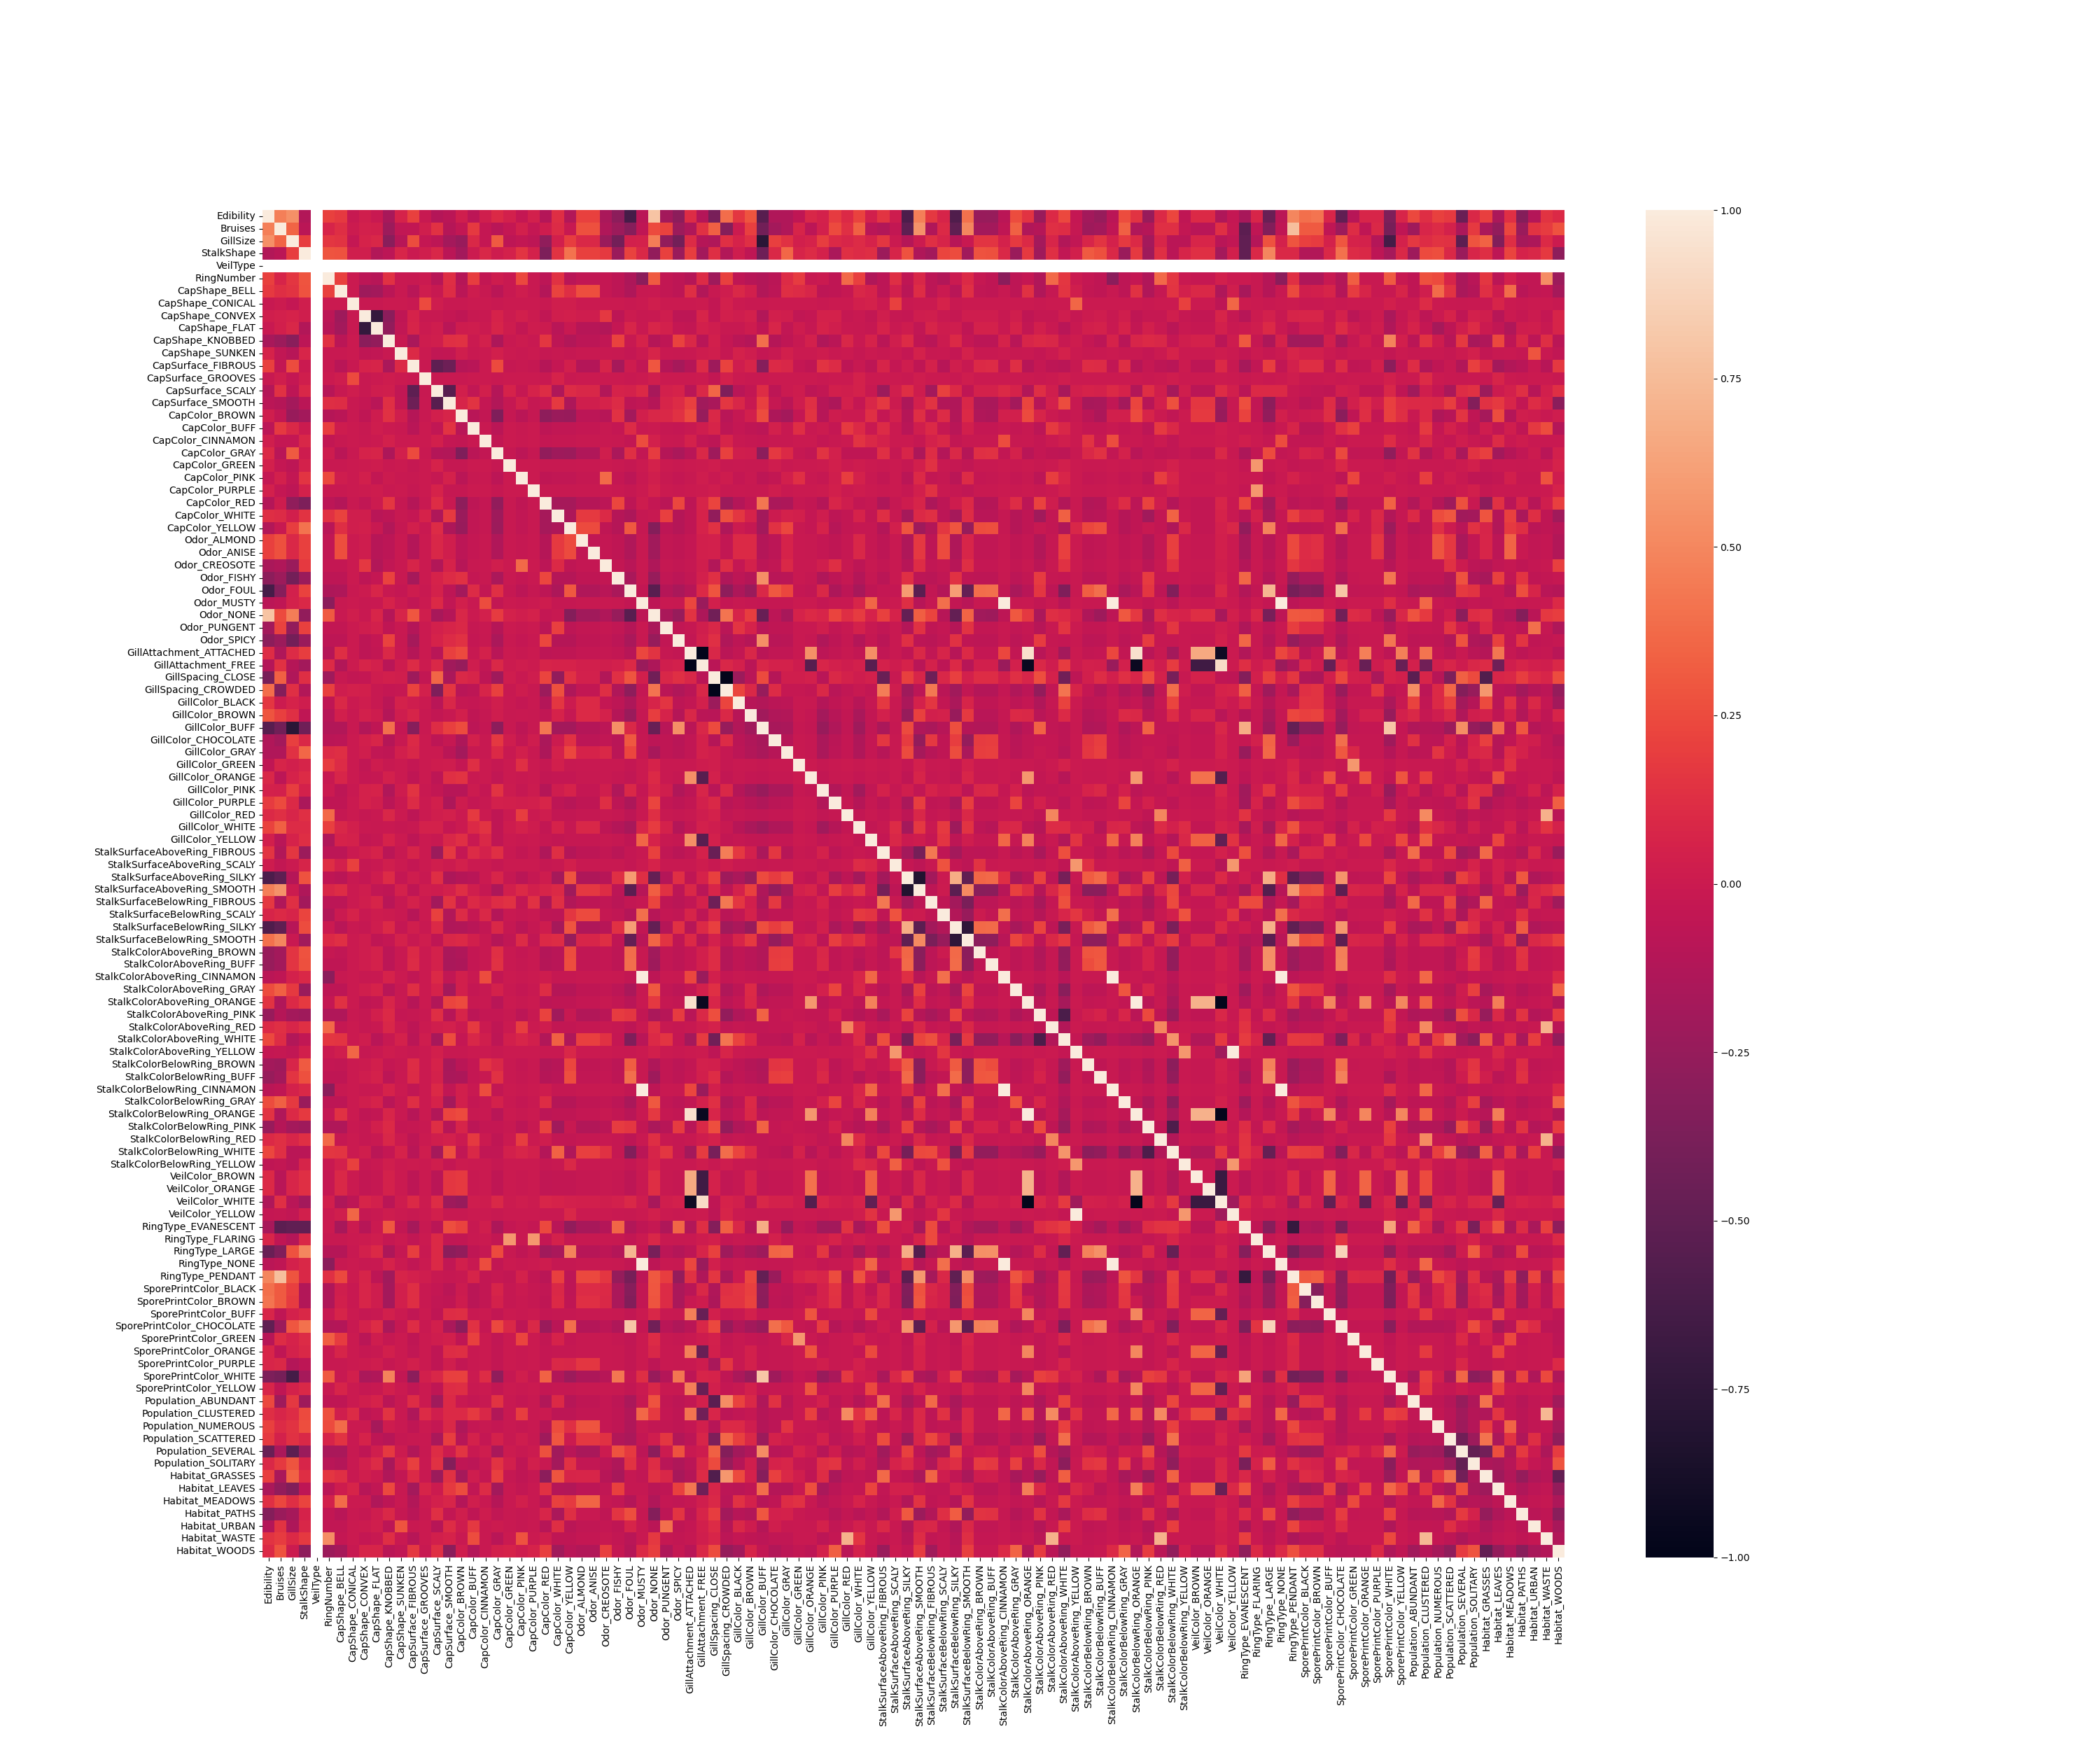


ModeImputed


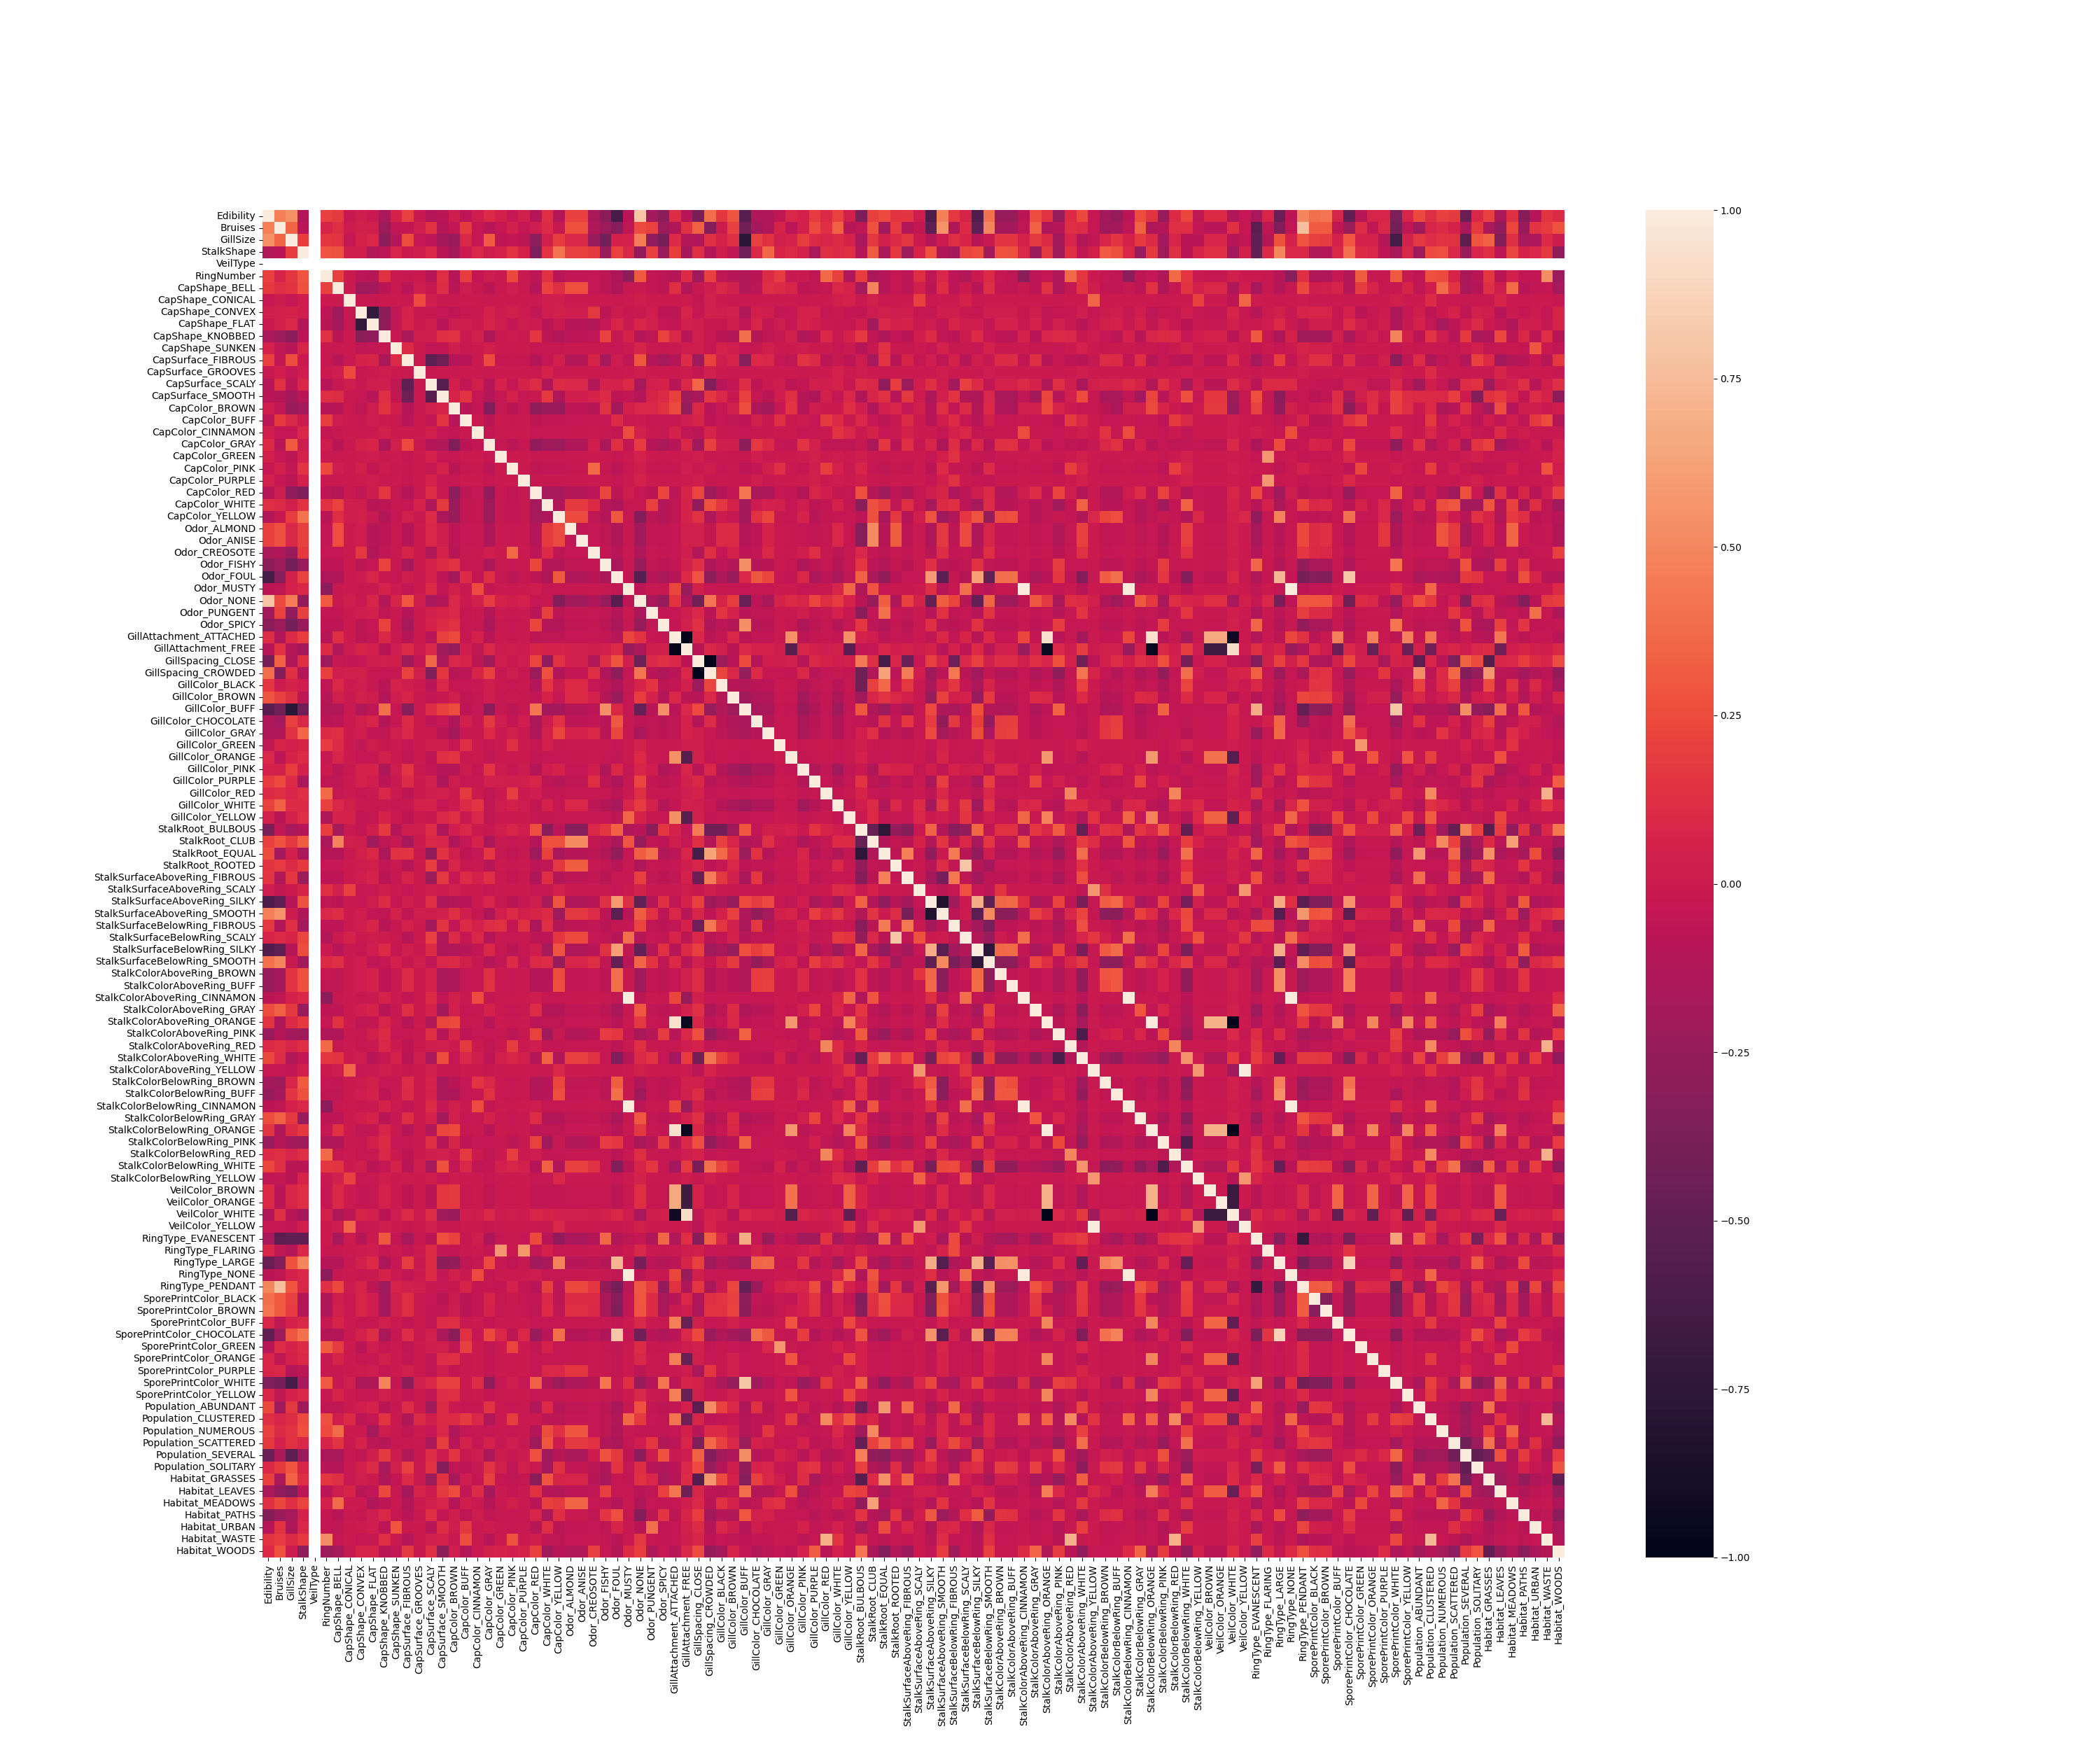

In [7]:
print("Heatmap Correlation")
print("NullsDropped")
pyplot.figure(figsize=(30, 25))
correlationMatrix = dfnullsdropped.corr()
seaborn.heatmap(correlationMatrix, annot=False)#Don't annotate because there's too many numbers for them to be meaningful individually.
pyplot.show()
print("")
print("ModeImputed")
pyplot.figure(figsize=(30, 25))
correlationMatrix = dfmodeimputed.corr()
seaborn.heatmap(correlationMatrix, annot=False)#Same thing here.
pyplot.show()
print("")

The heatmaps are relatively humongous, due to all the one-hot-encoding columns we've added; the amount of data here is too much for me to properly analyze closely, but I can express a few big picture insights.

One, the overall heatmap is very 0.0 correlation red; I expect this is a good sign, as low correlation means each feature is encoding different information to the others.

It also appears that many of the correlation spikes, as one might expect, are referring to the one-hot-encoding groups, clustered around the central diagonal line. However, there are also notable correlation spikes around the StalkSurfaceBelowRing x SporePrintColor and VeilColor x GillAttachment groupings, which may be of note later on or if we wanted to choose features to drop from the dataset.

Finally, one row of particular note is of course "Edibility". The features with the highest absolute correlation values were: Bruises, GillSize, Odor_FOUL, Odor_NONE, GillSpacing_CROWDED, GillColor_BROWN, GillColor_BUFF, StalkSurfaceAboveRing_SILKY, StalkSurfaceAboveRing_SMOOTH, StalkSurfaceBelowRing_SILKY, StalkSurfaceBelowRing_SMOOTH, RingType_LARGE, RingType_PENDANT, SporePrintColor_BLACK, SporePrintColor_BROWN, SporePrintColor_CHOCOLATE, SporePrintColor_WHITE, Population_SEVERAL, Habitat_PATHS. These features are the ones that are therefore most likely to be the most helpful in determining edibility; whether a mushroom has an Odor of FOUL or an odor of NONE correlates very strongly to a mushroom's edibility, thereby making Odor a very important feature for determining as much.

Of these, it is of note that several appear in the list of the six features listed as most important by https://www.mecs-press.org/ijigsp/ijigsp-v11-n4/IJIGSP-V11-N4-5.pdf, though not all. In particular, CapColor doesn't seem to have any particularly strong correlations based on this heatmap, which does disagree with the above research paper's assertion.

* #### Prepare Features and Split 
1.  Split your data into training and testing sets, using stratification.

In [8]:
droppedfeatures = dfnullsdropped.drop(columns=["Edibility"])
droppedlabels = dfnullsdropped["Edibility"]

#Split the data into training and testing feature tables, and training and testing label arrays
droppedfeatures_train, droppedfeatures_test, droppedlabels_train, droppedlabels_test = train_test_split(
    droppedfeatures,
    droppedlabels,
    test_size=0.2,
    random_state=42,
    stratify=droppedlabels
)



imputedfeatures = dfmodeimputed.drop(columns=["Edibility"])
imputedlabels = dfmodeimputed["Edibility"]

#Split the data into training and testing feature tables, and training and testing label arrays
imputedfeatures_train, imputedfeatures_test, imputedlabels_train, imputedlabels_test = train_test_split(
    imputedfeatures,
    imputedlabels,
    test_size=0.2,
    random_state=42,
    stratify=imputedlabels
)

print("Completed Calculations")

Completed Calculations


2. Print the shape of all four arrays (X_train, X_test, y_train, y_test). 

In [9]:
print("Split Data:")
print("Dropped")
print(droppedfeatures_train.shape)
print(droppedfeatures_test.shape)
print(droppedlabels_train.shape)
print(droppedlabels_test.shape)
print("")
print("Imputed")
print(imputedfeatures_train.shape)
print(imputedfeatures_test.shape)
print(imputedlabels_train.shape)
print(imputedlabels_test.shape)
print("")

Split Data:
Dropped
(6732, 107)
(1684, 107)
(6732,)
(1684,)

Imputed
(6732, 111)
(1684, 111)
(6732,)
(1684,)



3. In a markdown cell, verify that the survival rate is approximately the same in
both splits.

In [10]:
print("Value Counts:")
print("")
print("Dropped")
print(droppedlabels_train.value_counts())
print("Edibility Ratio:", droppedlabels_train.value_counts()[1] /  droppedlabels_train.value_counts()[0])
print(droppedlabels_test.value_counts())
print("Edibility Ratio:", droppedlabels_test.value_counts()[1] /  droppedlabels_test.value_counts()[0])
print("")
print("Imputed")
print(imputedlabels_train.value_counts())
print("Edibility Ratio:", imputedlabels_train.value_counts()[1] /  imputedlabels_train.value_counts()[0])
print(imputedlabels_test.value_counts())
print("Edibility Ratio:", imputedlabels_test.value_counts()[1] /  imputedlabels_test.value_counts()[0])
print("")

Value Counts:

Dropped
Edibility
1    3590
0    3142
Name: count, dtype: int64
Edibility Ratio: 1.1425843411839594
Edibility
1    898
0    786
Name: count, dtype: int64
Edibility Ratio: 1.1424936386768447

Imputed
Edibility
1    3590
0    3142
Name: count, dtype: int64
Edibility Ratio: 1.1425843411839594
Edibility
1    898
0    786
Name: count, dtype: int64
Edibility Ratio: 1.1424936386768447



The survival ratio is effectively the same for both sets, so the stratification worked nicely.

4. Verify that all features are numerical by printing X_train.dtypes. In a 
markdown cell, confirm that no string or Boolean columns remain. If any do, fix them 
now and explain what you have changed. 

In [11]:
print("Types:")
print("Dropped")
print(dfnullsdropped.dtypes)
print("")
print("Imputed")
print(dfmodeimputed.dtypes)
print("")

Types:
Dropped
Edibility                        int64
Bruises                          int64
GillSize                         int64
StalkShape                       int64
VeilType                         int64
RingNumber                       int64
CapShape_BELL                    int64
CapShape_CONICAL                 int64
CapShape_CONVEX                  int64
CapShape_FLAT                    int64
CapShape_KNOBBED                 int64
CapShape_SUNKEN                  int64
CapSurface_FIBROUS               int64
CapSurface_GROOVES               int64
CapSurface_SCALY                 int64
CapSurface_SMOOTH                int64
CapColor_BROWN                   int64
CapColor_BUFF                    int64
CapColor_CINNAMON                int64
CapColor_GRAY                    int64
CapColor_GREEN                   int64
CapColor_PINK                    int64
CapColor_PURPLE                  int64
CapColor_RED                     int64
CapColor_WHITE                   int64
CapColor_Y

As can be seen above, all of the columns remaining are int64 types, as intended.

### Part 2: Build Decision Tree

* #### Train an Unpruned Tree 
1. Train a DecisionTreeClassifier with criterion='entropy', random_state=42, and 
no other constraints (default parameters).  

2.  Report the training accuracy and testing accuracy. Print both values clearly. 

* #### Analyze the Overfitting
1. In a markdown cell, compare the training and testing accuracy. What do you 
observe? Is the model overfitting? How can you tell?

2) Print the depth of your unpruned tree using tree.get_depth() and the total 
number of leaves using tree.get_n_leaves(). In a markdown cell, comment on whether 
these numbers seem reasonable for a dataset of this size. 

3) Create a plot showing training accuracy vs. testing accuracy for max_depth 
values from 1 to 20. Use a line plot with two clearly labeled lines, axis labels, a legend, 
and a title.

4) In a markdown cell below the plot, describe what pattern you observe and at 
what depth the gap between training and testing accuracy starts to widen noticeably.

5) In a markdown cell: When max_depth=1, the tree is very shallow. Is this 
model more likely to suffer from underfitting or overfitting? What about when 
max_depth=20? Connect your answers to what you see in your plot above.

6. Based on your plot, what range of max_depth values appears to give the best 
balance between training and testing performance? Justify your answer. 

* #### Confusion Matrix

1. Generate and display a confusion matrix for the untuned tree on the test set.

2. In a markdown cell, interpret the confusion matrix: 
    1) How many True Negatives and True Positives did the model produce? 
    2) Which error type is more common, False Positives or False Negatives? 
    3) In the Titanic context, what is the real-world consequence of each error type? 
Which would you consider more costly and why? 

* #### Effect of Training Sample Size

1) Using your unpruned tree, train the model on increasing fractions of the 
training set: 10%, 25%, 50%, 75%, and 100%. For each fraction, record:
    1) training accuracy
    2) testing accuracy
    3) averaged training time. Create a figure with two subplots: one showing training and testing accuracy vs. training set size, and another 
showing training time vs. training set size.
Label all axes and include legends. 

2) In a markdown cell, analyze your plots. How does increasing training set size 
affect accuracy? Does the gap between training and testing accuracy shrink or grow? 
How does training time scale?  

### Part 3: Tuning max_depth with 5-Fold Cross-Validation (CV) 

* #### Find the Best max_depth 

1. You will loop over candidate depth values and use cross_val_score() to 
evaluate each one. It returns an array of 5 accuracy scores, one per fold. Record both the 
mean and the standard deviation of those 5 scores for each depth. 

2. Create a figure with two subplots (Label all axes, include titles, and add a 
legend where appropriate) 
    1) Subplot 1: Mean CV accuracy vs. max_depth with error bars representing the 
standard deviation.  
    2) Subplot 2: Cross-validation time vs. max_depth. 

3. In a markdown cell, identify the best max_depth based on the highest mean 
CV accuracy. Then answer: 
    1) If multiple depths give very similar mean CV accuracy, which would you prefer 
and why? Consider both the mean and the standard deviation. 
    2) Print the best max_depth with its mean CV accuracy and standard deviation. 

* #### Evaluate the Final Model on the Test Set 

1. Now that you have selected the best max_depth, retrain the final model on the 
full X_train and evaluate once on X_test. Report training accuracy and testing accuracy. 

2) Generate and display confusion matrix for both tuned and untuned model 
(already generated in 2.3) on the test set. In a markdown cell, compare the confusion 
matrices. Did tuning max_depth reduce any specific type of error? 

 3) Create a summary comparison table with columns: Max_depth | Mean CV Accuracy | Test Accuracy | Leaves | Time

4. Comment on the differences: Did the tuned model reduce overfitting? How does the 
number of leaves compare? How close is the mean CV accuracy to the final test 
accuracy?

* ####  Visualize the Tuned Tree

1. Visualize your tuned and untuned decision trees. Set feature_names to your 
column names.  